In [54]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Options: 0 = all, 1 = filter INFO, 2 = filter WARNING, 3 = ERROR only
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # disable GPU

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set memory growth to True
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

Physical devices cannot be modified after being initialized


In [55]:
!nvidia-smi

Thu Jul 10 21:09:18 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.77                 Driver Version: 565.77         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...    Off |   00000000:01:00.0  On |                  N/A |
| N/A   41C    P8              3W /  115W |    7785MiB /   8188MiB |     20%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from seaborn import heatmap

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, \
accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# New libraries
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(patience=3)

In [57]:
from sklearn.metrics import confusion_matrix
def eval_classification(model, X, y, name='model', labels=None):
    """Prints a classification report and confusion matrix
    Returns a dataframe with classification metrics.
    """
    preds = np.rint(model.predict(X))

    print(classification_report(y, preds, target_names=labels))

    # Display confusion matrix
    ConfusionMatrixDisplay.from_predictions(y, preds, display_labels=labels)
    plt.show()

    # Compute confusion matrix for FPR and FNR
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()

    # Initialize the score dataframe
    score_df = pd.DataFrame(index=[name])
    score_df.loc[name, 'Accuracy'] = accuracy_score(y, preds)
    score_df.loc[name, 'Precision'] = precision_score(y, preds)
    score_df.loc[name, 'Recall'] = recall_score(y, preds)
    score_df.loc[name, 'F1 Score'] = f1_score(y, preds)
    score_df.loc[name, 'False Positive Rate'] = fp / (fp + tn) if (fp + tn) > 0 else 0
    score_df.loc[name, 'False Negative Rate'] = fn / (fn + tp) if (fn + tp) > 0 else 0

    return score_df

def plot_history(history):
  print("""Takes a keras model learning history and plots each metric""")

  metrics = history.history.keys()
  print(metrics)
  for metric in metrics:
      if not 'val' in metric:
        plt.plot(history.history[f'{metric}'], label=f'{metric}')
        if f'val_{metric}' in metrics:
          plt.plot(history.history[f'val_{metric}'], label=f'val_{metric}')
        plt.legend()
        plt.title(f'{metric}')
        plt.show()

### Classification:
Classification models are similar, except that we need to adjust the final activation of the output layer, the loss function in the compile step, and the metrics we use to judge them. Remember: MAE, MSE, RMSE, and R2 are regression metrics, accuracy, recall, precision, F1-Score, and confusion matrices are classification metrics.

In [58]:
df_train = pd.read_csv('Split_Data/Model_Ready/train.csv')
df_train.head()
# Define X and y and train data
X_train = df_train.drop(columns = 'label')
y_train = df_train['label']

In [71]:
df_val = pd.read_csv('Split_Data/Model_Ready/val.csv')

# Define X and y and train data
X_val = df_val.drop(columns = 'label')
y_val = df_val['label']

In [72]:
df_val.shape

(13197, 144)

In [73]:
df_train.shape

(52792, 144)

### Build de Model

In [64]:
# Define the input shape
input_shape = (X_train.shape[1],)

class_model1 = Sequential([
    Input(shape=input_shape),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')  # binary classification
])

In [65]:
# Compile your model

# Since this is binary classification set loss  = 'binary_crossentropy'
# Set the metrics = ['acc']
class_model1.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['acc'])

In [66]:
# fit your model
history = class_model1.fit(X_train, y_train,
                        validation_data = (X_val, y_val),
                        epochs = 500,
                        verbose=0,
                          callbacks=[early_stopping])

Takes a keras model learning history and plots each metric
dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])


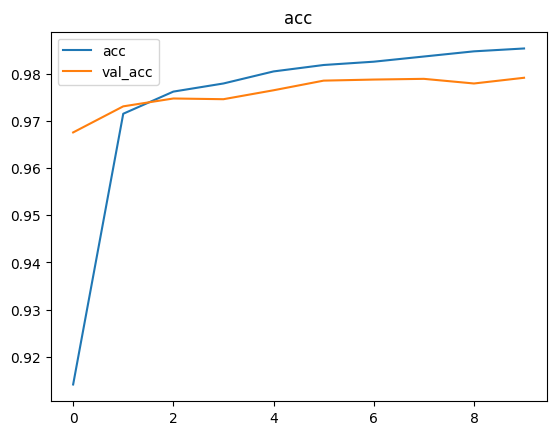

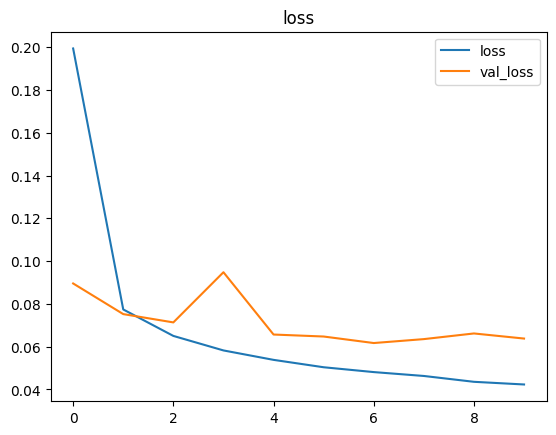

In [67]:
# See how your model is doing
plot_history(history)

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 626us/step
                   precision    recall  f1-score   support

No Phishing Email       0.99      0.98      0.99     25308
   Phishing Email       0.99      0.99      0.99     27484

         accuracy                           0.99     52792
        macro avg       0.99      0.99      0.99     52792
     weighted avg       0.99      0.99      0.99     52792



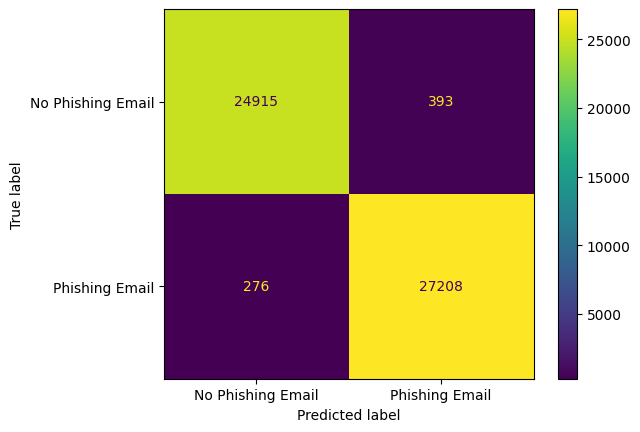

Val Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step
                   precision    recall  f1-score   support

No Phishing Email       0.98      0.98      0.98      6301
   Phishing Email       0.98      0.98      0.98      6896

         accuracy                           0.98     13197
        macro avg       0.98      0.98      0.98     13197
     weighted avg       0.98      0.98      0.98     13197



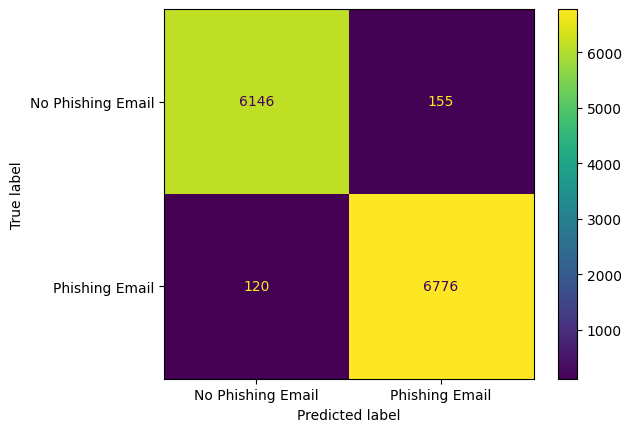

,Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate
class_model1 train,0.987328,0.985761,0.989958,0.987855,0.015529,0.010042
class_model1 val,0.979162,0.977637,0.982599,0.980111,0.024599,0.017401


In [69]:
# Make predicitons and evaluate your model
# Define labels for the confusion matrix
labels = ['No Phishing Email', 'Phishing Email']

# Evaluate training set
print('Training Evaluation:\n')
train_scores = eval_classification(class_model1,
                             X_train, y_train,
                             name='class_model1 train',
                             labels=labels)
print('Val Evaluation:\n')
# Confusion Matrix
val_scores = (eval_classification(class_model1,
                                           X_val, y_val,
                                           name='class_model1 val',
                                           labels=labels))

scores = pd.concat([train_scores, val_scores])
scores